In [1]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint_adjoint as odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch


/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
os.chdir("/home/wergillius/Project/PINN_dynamics")

In [5]:
ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_5/checkpoints/epoch=17-total_loss=0.31139943.ckpt"


date = time.strftime("%b%d")
result_dir = "results/" + "/".join(ckpt_path.split("/")[1:3]) + f"_{date}_onbase"
result_base = re.match(r".*/(version_\d{1,2})/.*", ckpt_path).group(1)

In [6]:
data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

In [144]:
bg_g = np.load("results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov13_onbase/version_5_g.npy")
bg_v = np.load("results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov13_onbase/version_5_v.npy")
bg_D = np.load("results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov13_onbase/version_5_D.npy")

In [145]:
def params_into_df(local_v_name):

	param = globals()[local_v_name]
	p = local_v_name.split("_")[-1]
	param_col = [f'Day{t}_{p}' for t in ['2', '4','6']]
	param_df = pd.DataFrame(param.T, columns=param_col)

	return param_df

In [146]:
bg_params = pd.concat([params_into_df("bg_g"), params_into_df("bg_D")], axis=1)

In [147]:
bg_params.index = adata.obs_names
bg_params['label_man'] = adata.obs['label_man']

In [148]:
adata.obs['label_man'].nunique()

22

In [133]:
bg_params

,Day2_g,Day4_g,Day6_g,Day2_D,Day4_D,Day6_D,label_man
0,4.603798,5.332360,5.407269,-9.094235,-7.803683,-6.530519,prog_2
1,6.115653,6.299159,6.263654,-8.059117,-5.919086,-4.014857,prog_Baso_Meg_Ery_Mast
2,-1.840067,3.293439,4.696149,-9.032227,-7.890337,-6.450914,prog_Mono
4,6.289052,6.320133,6.243479,-8.340015,-6.673374,-5.093782,prog_Meg_Ery
6,3.762875,3.855896,3.936209,-10.218608,-10.356840,-10.239678,prog_Neu
...,...,...,...,...,...,...,...
130875,6.277824,6.317698,6.242498,-8.486077,-6.796941,-5.203563,prog_Meg_Ery
130876,4.658546,5.458598,5.528747,-8.756544,-7.453511,-6.223175,prog_2
130877,4.290519,4.576040,4.687253,-10.034097,-9.951090,-9.530695,early_prog_Neu
130879,-5.103699,-4.101942,-0.435361,-8.228955,-7.124247,-5.480642,prog_Mono


# read meta clone data and parameters

In [8]:
clone0_ad = sc.read_h5ad("data/Weinreb_clone0.h5ad")
clone1_ad = sc.read_h5ad("data/Weinreb_clone1.h5ad")
clone2_ad = sc.read_h5ad("data/Weinreb_clone2.h5ad")
clone3_ad = sc.read_h5ad("data/Weinreb_clone3.h5ad")
clone4_ad = sc.read_h5ad("data/Weinreb_clone4.h5ad")

(-9.760050201416016,
 17.716837310791014,
 -8.402615928649903,
 14.636132621765137)

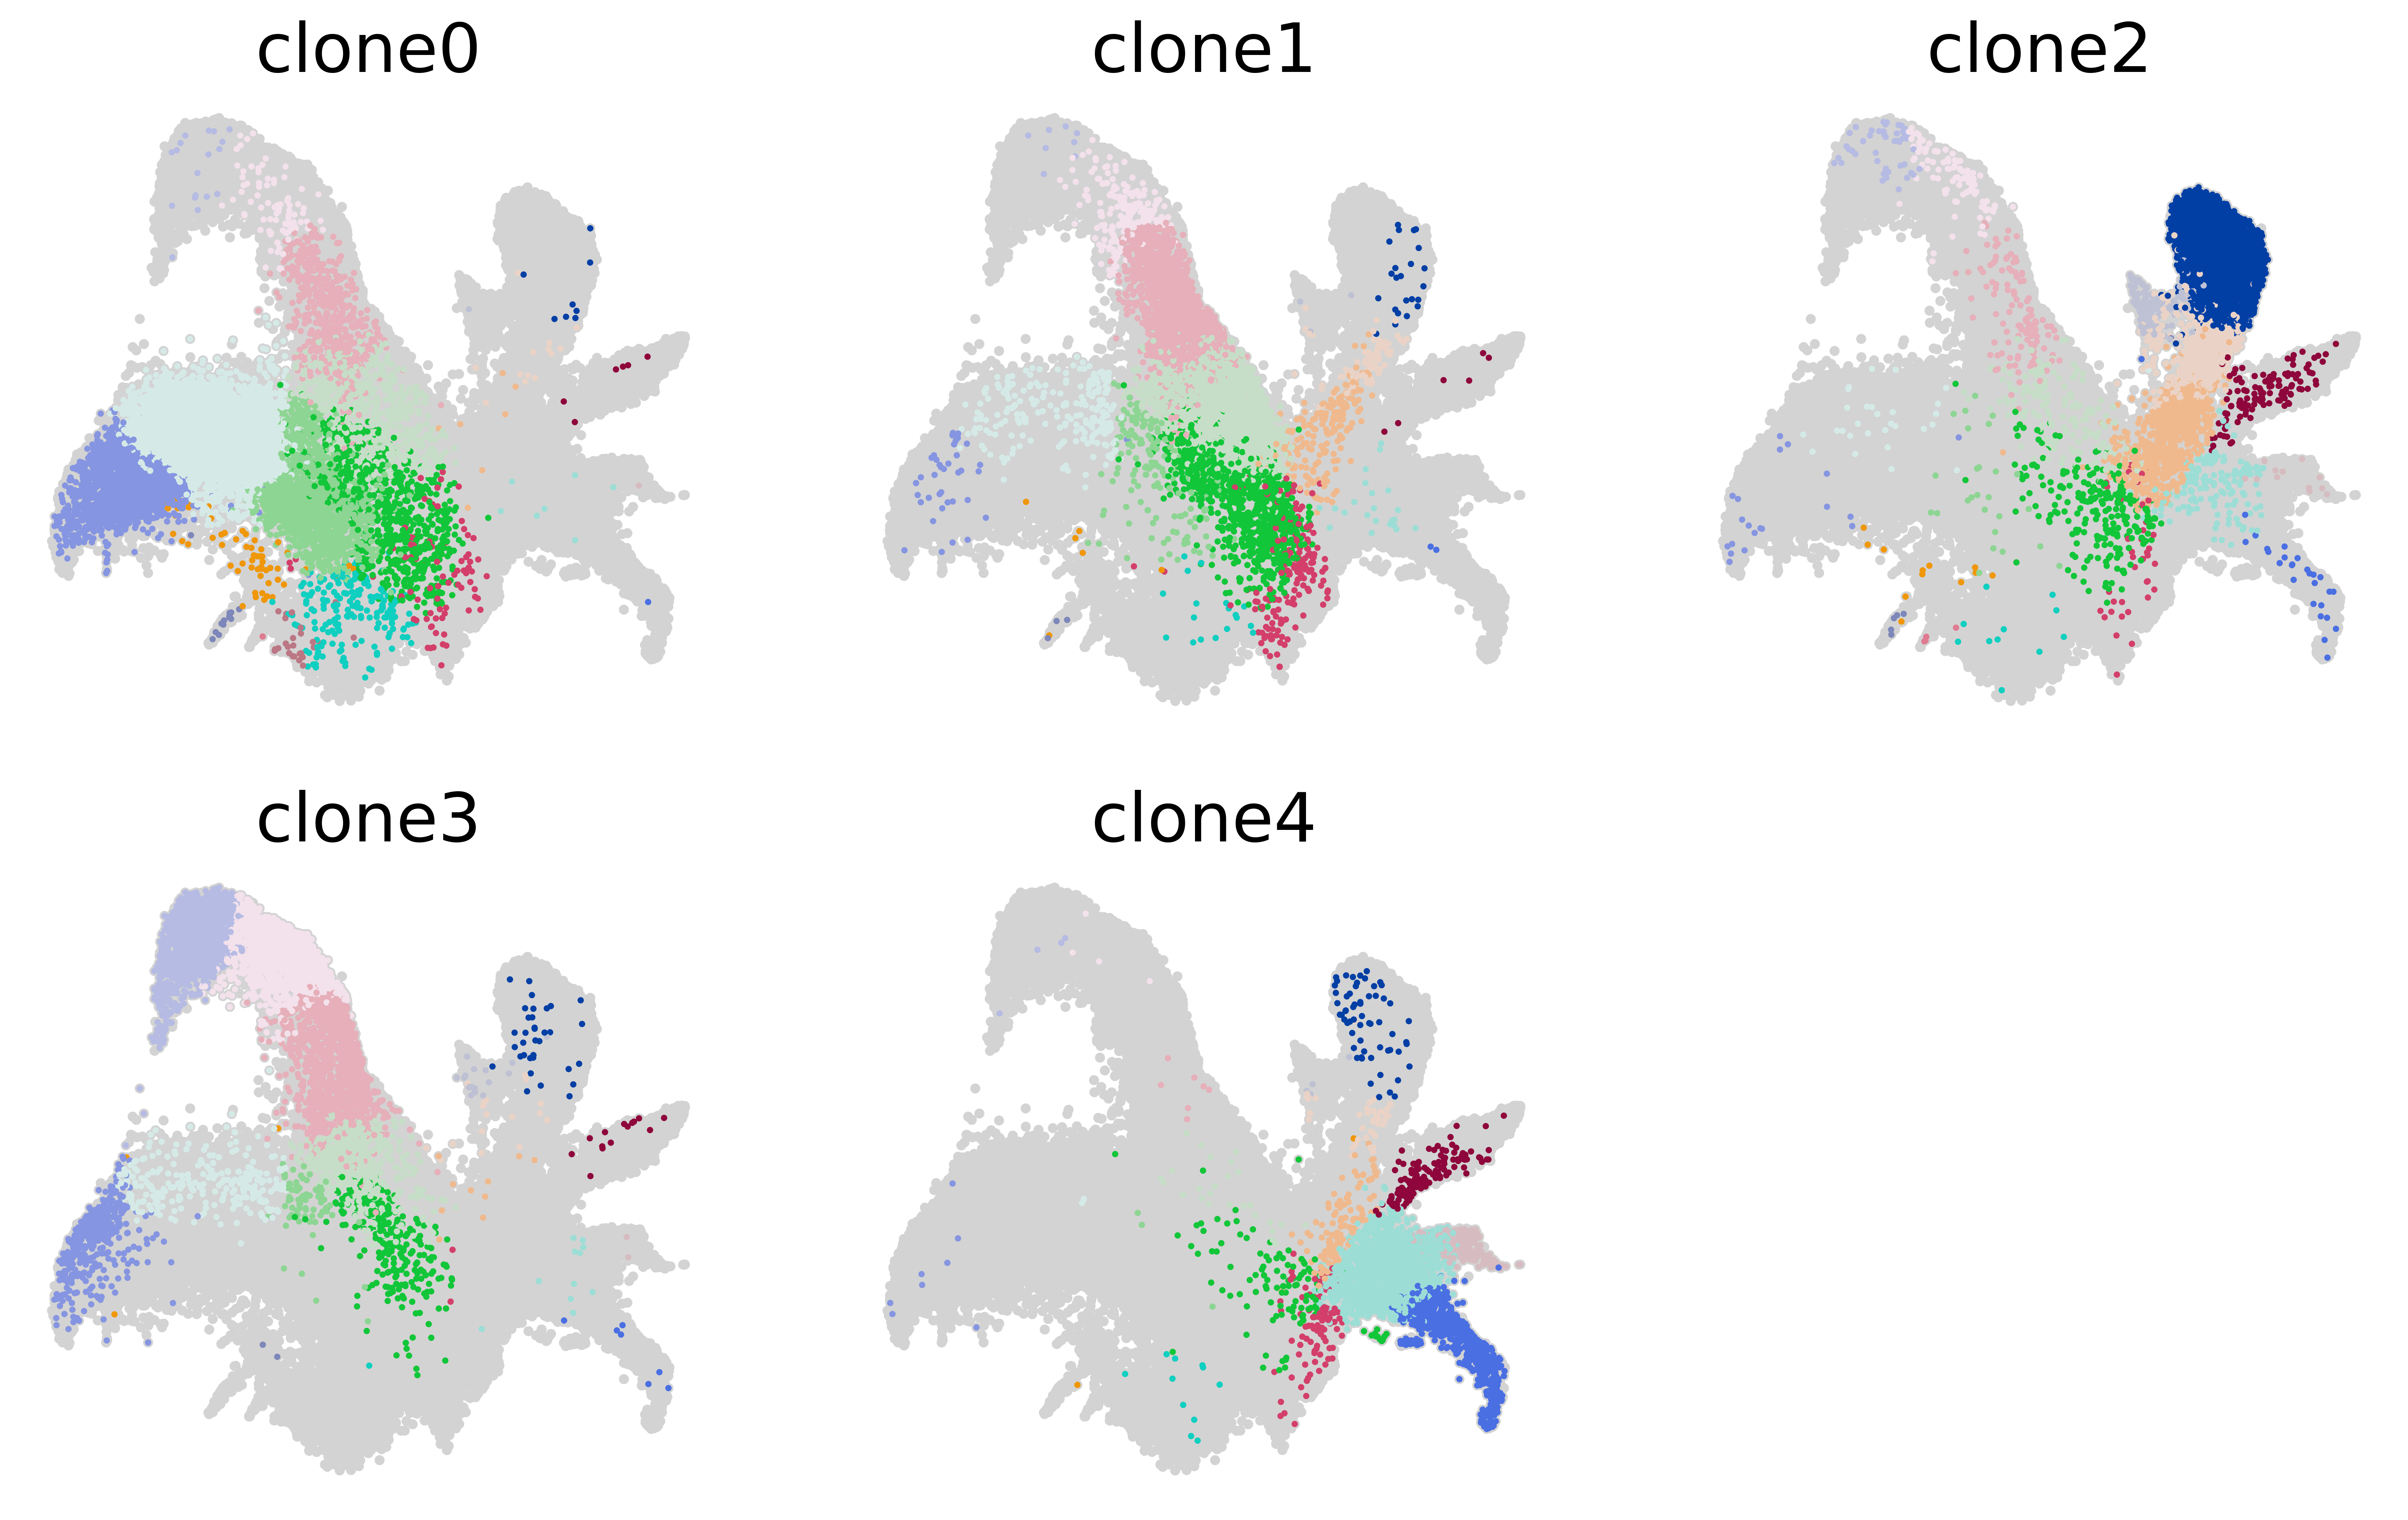

In [ ]:
fig, axs = plt.subplots(2,3, figsize=(15, 9), dpi=600, sharey=True, sharex=True, frameon=False)

axs = axs.flatten()


for i in range(5):
	sc.pl.umap(adata, size=50, ax=axs[i], show=False, frameon=False, return_fig=False)

	clone_ad = globals()[f'clone{i}_ad']
	sc.pl.umap(clone_ad, size=20, ax=axs[i], legend_loc='none', color='label_man', 
				frameon=False, show=False,  return_fig=False)

	axs[i].set_title(f'clone{i}', fontsize=24)

axs[-1].axis("off")

In [248]:
# clonal specific parameters
clone0_D = np.load("results/Weinreb_clone0-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_1_D.npy")
clone0_g = np.load("results/Weinreb_clone0-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_1_g.npy")

clone1_D = np.load("results/Weinreb_clone1-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_2_D.npy")
clone1_g = np.load("results/Weinreb_clone1-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_2_g.npy")

clone2_g = np.load("results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_2_g.npy")
clone2_D = np.load("results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_2_D.npy")
clone2_v = np.load("results/Weinreb_clone2-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_2_v.npy")

clone3_g = np.load("results/Weinreb_clone3-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_1_g.npy")
clone3_D = np.load("results/Weinreb_clone3-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_1_D.npy")


clone4_g =  np.load("results/Weinreb_clone4-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_3_g.npy")
clone4_D =  np.load("results/Weinreb_clone4-DM_EigenVectors_multiscaled_n3/pde_params_tsense_Nov06/version_3_D.npy")

In [249]:
for c in [str(i) for i in range(5)]:
	clone_params = pd.concat([params_into_df(f"clone{c}_g"), params_into_df(f"clone{c}_D")], axis=1)
	clone_params.index = globals()[f'clone{c}_ad'].obs_names
	clone_params = clone_params.merge(globals()[f'clone{c}_ad'].obs.copy(), left_index=True, right_index=True, how='left')
	clone_params.index = globals()[f'clone{c}_ad'].obs_names
	clone_params['clone'] = f'clone{c}'
	globals()[f'clone{c}_params'] = clone_params

In [250]:
param_dfs = [globals()[f'clone{c}_params'] for c in range(5)]

In [251]:
g_col = ['Day2_g', 'Day4_g', 'Day6_g']
D_col = ['Day2_D', 'Day4_D', 'Day6_D']

In [252]:
len(ct_cats)

22

In [262]:
def get_clone_agg_param(clone_params, min_cells=40):
	
	# aggregate
	ct_agg_params = clone_params.groupby('label_man').agg({c:'mean' for c in g_col+D_col})
	bg_agg = bg_params.loc[clone_params.index].groupby('label_man').agg({c:'mean' for c in g_col+D_col})

	# filter out infrequent cells
	celltype_count = clone_params.groupby('label_man').agg({'Time_point':'count'})
	infre_cts = celltype_count[celltype_count['Time_point'] < min_cells].index
	bg_agg.loc[infre_cts, g_col+D_col] = np.nan
	ct_agg_params.loc[infre_cts, g_col+D_col] = np.nan


	ct_cats = bg_params.label_man.cat.categories

	# pad_missing ct
	absent_ct = [ct for ct in ct_cats if ct not in list(ct_agg_params.index)]
	pad_df = pd.DataFrame(np.full((len(absent_ct), 6), fill_value=np.nan), columns=g_col+D_col)
	pad_df.index= absent_ct


	ct_agg_params = pd.concat([ct_agg_params, pad_df], axis=0).loc[ct_cats]
	# bg_agg = pd.concat([bg_agg, pad_df], axis=0).loc[ct_cats]
	
	return ct_agg_params, bg_agg

In [263]:
# vislize 

g_changes = []
for vs_col in g_col:

	g_fc = []
	for df in param_dfs:
		ct_agg_params, bg_agg = get_clone_agg_param(df)
		print(ct_agg_params.shape, bg_agg.shape)
		fc_df = ct_agg_params - bg_agg

		g_fc.append(fc_df[vs_col].values)

	g_changes.append(np.stack(g_fc))

g_changes = np.stack(g_changes) 

(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)
(22, 6) (22, 6)


/tmp/ipykernel_14641/1846298711.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_agg_params = clone_params.groupby('label_man').agg({c:'mean' for c in g_col+D_col})
/tmp/ipykernel_14641/1846298711.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bg_agg = bg_params.loc[clone_params.index].groupby('label_man').agg({c:'mean' for c in g_col+D_col})
/tmp/ipykernel_14641/1846298711.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence 

In [264]:
from matplotlib.colors import Normalize

In [265]:
g_norm = Normalize(vmin=-10, vmax=10)

In [266]:
import matplotlib.pyplot as plt

Text(0, 0.5, '\n\n\n\n\n\nthe change growth rate for clone\n (clone speicifc rate - background) ')

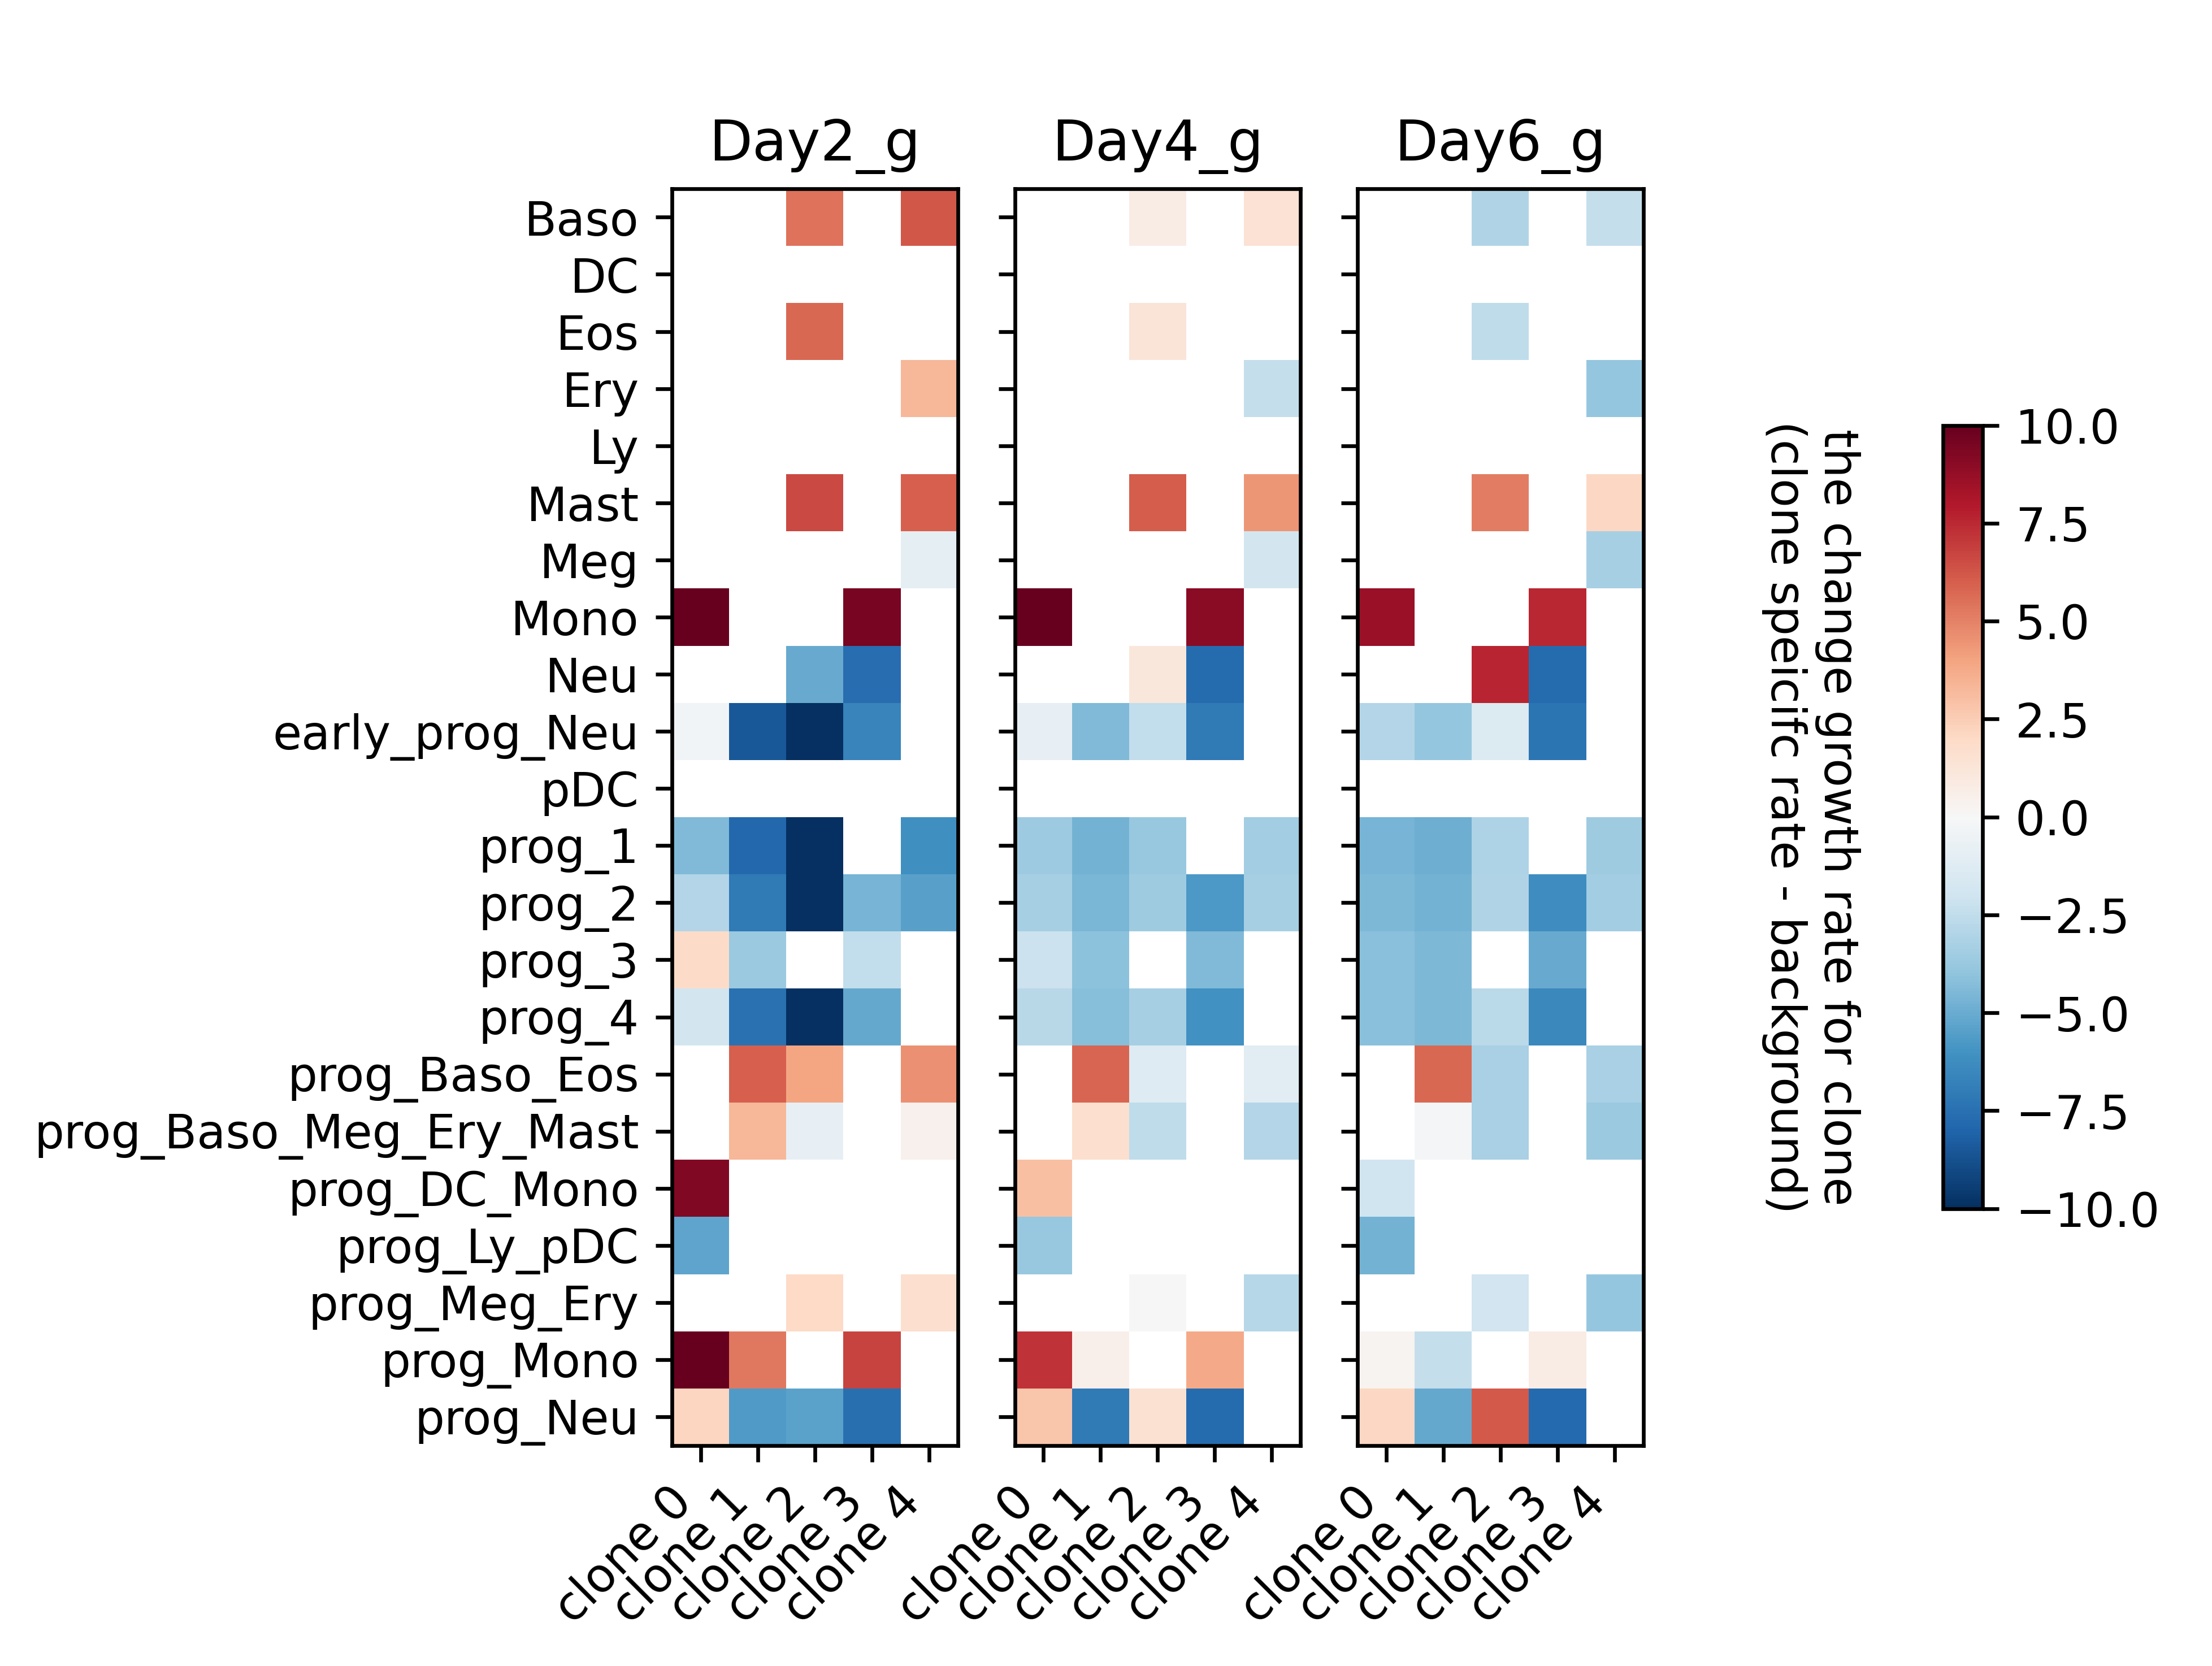

In [267]:
fig, axs = plt.subplots(1,4, figsize=(5, 6), dpi=600, sharey=True, frameon=False)



for i,  vs_col in enumerate(g_col):
    
	g = axs[i].imshow(g_changes[i].T, norm=g_norm, cmap='RdBu_r')

	axs[i].set_xticks(range(5))
	axs[i].set_xticklabels([f'clone {c}' for c in range(5)], rotation=45, ha='right')

	axs[i].set_title(vs_col)

axs[0].set_yticks(range(len(bg_agg.index)))
axs[0].set_yticklabels(bg_agg.index)

axs[3].axis('off')

cbar = plt.colorbar(g, ax=axs[3], shrink=0.5)
cbar.ax.set_ylabel("\n\n\n\n\n\nthe change growth rate for clone\n (clone speicifc rate - background) ", rotation=270)

In [270]:
adata.obs.clones.nunique()

5856